# Simulated Snalysis: Behavioral Correlates in Neural Recordings


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

## Motivation

The purpose of this exercise is to illustrate how simulations can be used to validate a data analysis 
*workflow* prior to looking at the data, or even prior to collecting the data. As a toy example we'll work 
up code to test a hypothesis in a dataset such as the 
[visual behavior ophys dataset](https://allenswdb.github.io/physiology/ophys/visual-behavior/VB-Ophys.html). 

Suppose we hypothesize the existence of a distributed network of cells (neurons) in the brain responsible for 
the cognitive state of being "on task" or "in the zone", such that the animal's task performance is higher when 
this group of neurons is more active. To look for such neurons, we plan to record from a large population of 
individual cells while an animal performs a task, and then search for cells whose activity is correlated with 
the animal's **behavioral performance** (for example, its accuracy on a change detection task). 

We have an idea for the workflow, following a pattern used in many published studies:

* Screen the population for any cells whose activity significantly correlates with behavioral 
performance.
* If any are found, define this group of cells as the population of interest, and summarize the time-varying 
activity of this population by averaging the activity of the cells.
* Test how well this aggregate population activity correlates with performance.

Before touching data we can simulate fake data and use it 
to develop and validate the proposed analysis workflow. The value of this is threefold: first, it is vastly easier 
to simulate data than to collect or extract it, so this is by far the easiest way to validate (or invalidate) a 
proposed analyis. Second, when we simulate data it forces us to be explicit about all our assumptions. 
But most importantly, when 
we simulate data we have access to the **ground truth** about whether the hypothesized effect is present or absent, 
and if present, exactly which cells participate, how strong the effect is, and so on. Therefore we can compare the 
output of our proposed analysis workflow to what we know to be the true answer -- a luxury we never have when 
we turn to real data.

## Roadmap of this workshop
- **Part 1 (this notebook) implement analysis on simulated random data** Simulate data with no real effect and analyze it by our proposed workflow
-  **Part 2: (next notebok) refine the analysis**: Explore ways of overcoming any pitfalls of the analysis we discovered in Part 1
- **Part 3: (time permitting) simulate ground truth of a real effect** Apply our refined analysis workflow(s) to fake data in which we simulate a genuine effect.

There are three follow-up extension notebooks you can explore on your own:

-  **Extension 1: Power calculations.** Building on Part 3, sweep effect size and sample size 
systematically to see how much data we would need for each alternative analysis method we 
came up with so far.
-  **Extension 2: Try it on real data.** Building on Part 2, a scaffold to get you started on 
loading real data so you can check if the assumptions of your analysis are true, or try running
any validated analysis pipeline(s) on real data.
- **Extension 3: Further refinements.** Additional explorations and further refinements to illustrate
and address remaining limitations of the analysis after the refinement ideas in Part 2.

</div>



<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

## Notes on key functions used:

We rely entirely on `numpy` random number distribution and `scipy.stats` statistical functions:

- `scipy.stats.pearsonr` for the per-cell correlation with performance (one cell at a time in
  the single-run analyses, or with `axis=0` in the heavier repeated simulations),
- `scipy.stats.linregress` for the best-fit line in the scatter plots

</div>



<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

# Step 1 Simulate Data with No Real Effect

Behavioral performance is not defined for a single trial. Therefore we will need to split each
session into short groups of trials. A good compromise between estimation accuracy and temporal
 resolution might be `Ntrials = 20` trials per group.

We could have simulated cell activity and trial outcome for each trial, but since we know we will be
analyzing the data in blocks of trials, we will skip ahead and just simulate the random values for
each group of trials.  We will assume a typical session contains about 400 trials, 
so `Ngroups = 20` groups of trials.

</div>



<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

## Simulating behavior 

For each trial group we will measure the animal's behavioral performance on the 
task, giving a performance score $P$ (e.g. percent correct). To simulate the assumption
that performance fluctuates over a session, we can draw a
score for each trial group at random from a normal distribution with mean $\mu_P = 75$ and
standard deviation $\sigma_P = 8$.  

*Notice that this implies a specific model for exactly how performance fluctuates*

</div>



<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

Note: If our simulations were truly random, we would all see different results each time we run this code, potentially causing confusion (and issues with version control). 
Instead, we use a pseudo-random number generator (in numpy) and fix a "seed" so the results will be reproducible.

</div>


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Set a seed so the notebook is reproducible (remove for fresh random draws)
rng = np.random.default_rng(0)

In [2]:
Ngroups = 20
mP, sP = 75, 8
Perf = sP * rng.standard_normal(Ngroups) + mP
Perf = np.round(Perf)  # not required, but make performance an integer percent
Perf


array([76., 74., 80., 76., 71., 78., 85., 83., 69., 65., 70., 75., 56.,
       73., 65., 69., 71., 72., 78., 83.])


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

## Simulating neural recordings

We are thinking of analyzing data with calcium imaging recordings so we'll simulate that.

Within a single animal we expect to image around `Ncells = 200` cells (neurons). For each trial group we
will measure each cell's average "activity" relative to pre-trial basline during the parts of the trial that are 
the same across all trials, averaged over the trials in the trial group. We will keep the activity 
in a matrix (numpy array) of shape `(Ngroups, Ncells)`.

We will simulate the null case, in which **no** cell's activity actually correlates with performance.
To simulate this, the activity of each cell in each time block is simulated as
noise drawn from a normal distribution with mean 0 and standard deviation $\sigma_A = 1$.

Each cell also has a **spatial position** in the imaging field.
In real data, these positions would let us visualize *where* the cells that appear
correlated with performance sit in the tissue.  For our fake data, the spatial positions 
can be drawn uniformly on the unit square $[0, 1]^2$.

</div>


In [3]:
Ncells = 200

sA = 1  # noise std of each cell's average activity
DA = sA * rng.standard_normal(size=(Ngroups, Ncells))

# Random 2D spatial position for each cell (uniform on the unit square).
# Note that we don't introduce any spatial dependence for the activity, but we could explore that here
CellXY = rng.uniform(0.0, 1.0, size=(Ncells, 2))


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

## Proposed  Analysis Workflow 
This is a *within-animal*, *within-session* analysis: we can't identify corresponding cells
in different animals, and we aren't sure we can find the same cells from session to session within 
animal, so we will correlate cell activity with behavioral performance across trial-groups within a single session.
We can of course apply that analyisis to all the sessions from an animal and all the a
 
Here are the analysis steps we will follow in more detail:

1. **Correlate each cell's activity with performace** 
For each cell in turn, take its activity in each trial group and the performance $P$ 
in each trial group, and test whether these are correlated. 
This gives $r$ values and $p$ values for each cell.

2. **Define the "selected" cells** as all cells *positively* correlated with $P$ under
   the criteria $r > 0.1$ **and** $p < 0.05$
   
3. **Average the activity of the selected cells** to get a
   single "Performance-Related Cell Activity" (PRCA) value per trial group.

4. **Scatter plot** PRCA versus performance $P$ (1 symbol per trial group, 20 trial groups).

5. **Fit a line** and label the plot with thg the correlated cells analysis

</div>


In [4]:
# 1. Correlate each cell's average activity with performance,
#    one cell at a time using scipy.stats.pearsonr.
r = np.empty(Ncells)
p = np.empty(Ncells)
for j in range(Ncells):
    r[j], p[j] = stats.pearsonr(DA[:, j], Perf)

# 2. "Selected" cells: positive correlation r > 0.1 AND significant p < 0.05.
SelectedCells = np.where((r > 0.1) & (p < 0.05))[0]

# 3. Average the average activity of the selected cells within each trial group.
PRCA = DA[:, SelectedCells].mean(axis=1)
print(f"Number of 'selected' cells: {SelectedCells.size}")


Number of 'selected' cells: 5



<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

## Plot the results

For each trial group, plot Performance-Related Cell Activity (PRCA) vs. the behavioral
performance, then add a best-fit line and the $R^2$ / p-value of the 
correlation.

</div>


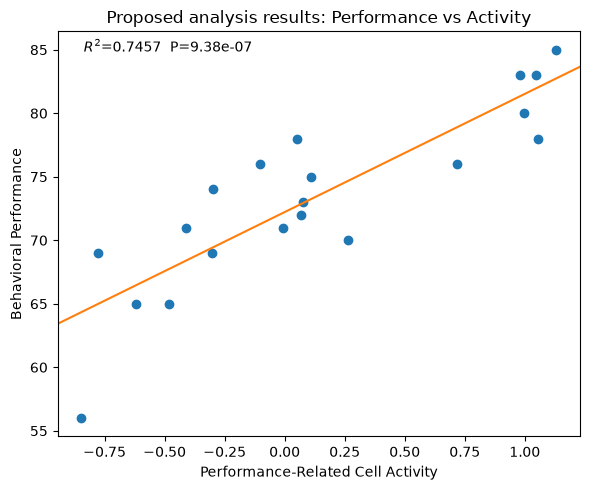

In [5]:
# Build a function that takes an axis, the Performance-Related Cell Activity, and the performance, 
# and annotates the axis with a scatter plot, a linear regression line, and the R^2 and p-value of the correlation.  
def annotate_corr(ax, PRCA, Perf, title):
    ax.plot(PRCA, Perf, "o", color="tab:blue", markerfacecolor="tab:blue")
    fit = stats.linregress(PRCA, Perf)
    xl = np.array(ax.get_xlim())
    ax.plot(xl, fit.slope * xl + fit.intercept, "-", color="tab:orange")
    ax.set_xlim(xl)
    ax.set_xlabel("Performance-Related Cell Activity")
    ax.set_ylabel("Behavioral Performance")
    ax.set_title(title)
    Rsquared = fit.rvalue ** 2
    xlims, ylims = ax.get_xlim(), ax.get_ylim()

    xpos = xlims[0] + 0.05 * (xlims[1] - xlims[0])
    ypos = ylims[1] - 0.05 * (ylims[1] - ylims[0])
    ax.text(xpos, ypos, f"$R^2$={Rsquared:.4f}  P={fit.pvalue:.2e}")


fig, ax = plt.subplots(figsize=(6, 5))
annotate_corr(ax, PRCA, Perf, "Proposed analysis results: Performance vs Activity")
plt.tight_layout()
plt.show()



<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

## What to think about

The ground truth here is that cell activity is completely unrelated to behavioral
performance — yet the scatter typically shows a convincing-looking positive trend with a high
$R^2$ and a small $p$ value.

- Do you believe this result?
- How do these selected "Performance-related cells" compare to the rest of the recorded cells?

</div>


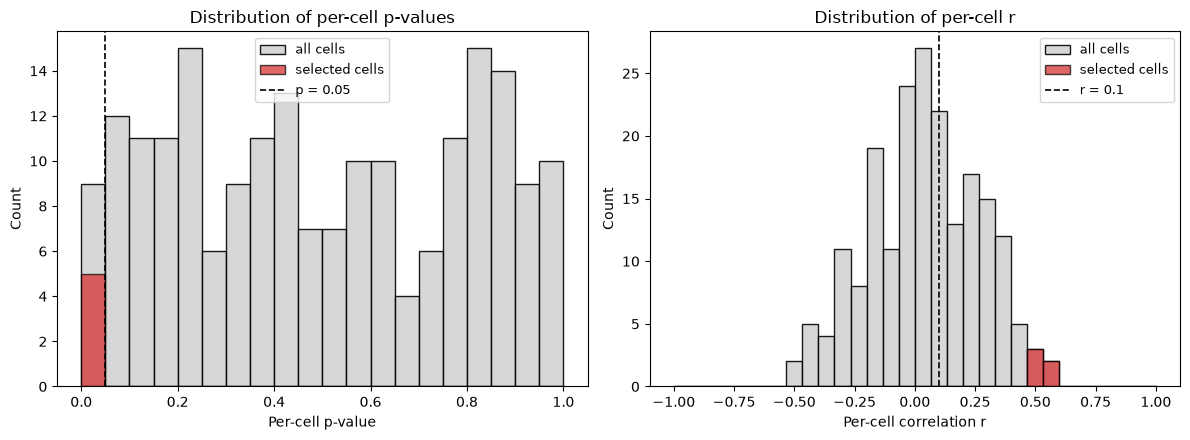

In [6]:
# Plot distributions of p-values and r for all cells, with selected cells highlighted.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# p-values
bins_p = np.linspace(0, 1, 21)
axes[0].hist(p, bins=bins_p, color="lightgray", edgecolor="k", alpha=0.9, label="all cells")
if SelectedCells.size > 0:
    axes[0].hist(p[SelectedCells], bins=bins_p, color="tab:red", edgecolor="k", alpha=0.7,
                 label="selected cells")
axes[0].axvline(0.05, color="k", linestyle="--", linewidth=1.2, label="p = 0.05")
axes[0].set_xlabel("Per-cell p-value")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of per-cell p-values")
axes[0].legend(fontsize=9)

# r-values
bins_r = np.linspace(-1, 1, 31)
axes[1].hist(r, bins=bins_r, color="lightgray", edgecolor="k", alpha=0.9, label="all cells")
if SelectedCells.size > 0:
    axes[1].hist(r[SelectedCells], bins=bins_r, color="tab:red", edgecolor="k", alpha=0.7,
                 label="selected cells")
axes[1].axvline(0.1, color="k", linestyle="--", linewidth=1.2, label="r = 0.1")
axes[1].set_xlabel("Per-cell correlation r")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of per-cell r")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

## Is this result consistent?

A single run either clears the $p < 0.05$ bar or it doesn't — it could be due to a quirk of our analysis. 
To address this, we repeat the simulation many times (fresh cell activity each run, the same fixed `Perf`) and
collect the final $p$-value and $R^2$ from every run.

</div>


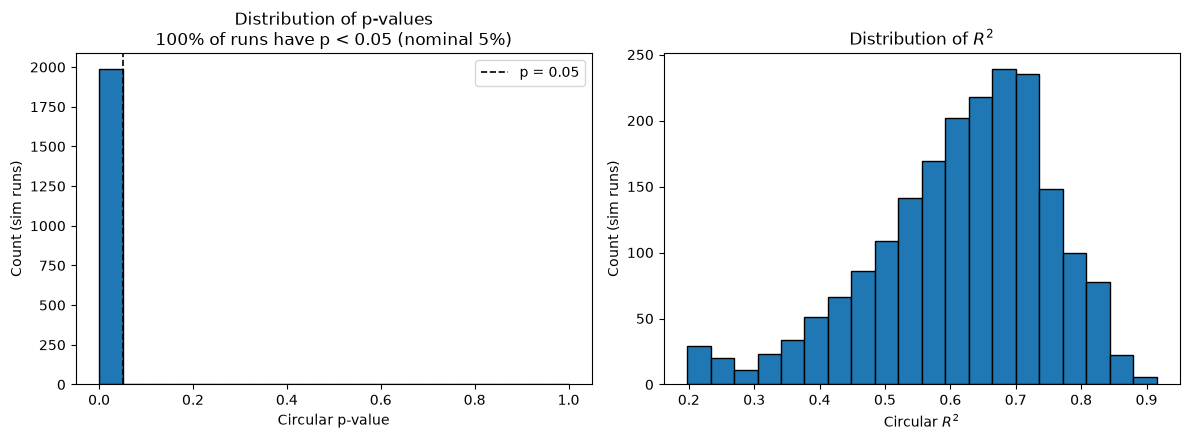

Results over 2000 runs:
  fraction with p < 0.05 : 100.0%  (nominal 5%)
  median R^2             : 0.639


In [7]:
# Repeat the proposed analysis many times and collect p and R^2.
N_sim = 2000
pvals_sim = []
r2_sim = []
for _ in range(N_sim):
    DA_n = sA * rng.standard_normal((Ngroups, Ncells))
    res = stats.pearsonr(DA_n, Perf[:, np.newaxis], axis=0)
    sel = np.where((res.statistic > 0.1) & (res.pvalue < 0.05))[0]
    if sel.size == 0:
        continue
    rr, pp = stats.pearsonr(DA_n[:, sel].mean(axis=1), Perf)
    pvals_sim.append(pp)
    r2_sim.append(rr ** 2)

pvals_sim = np.array(pvals_sim)
r2_sim = np.array(r2_sim)
frac_sig = np.mean(pvals_sim < 0.05)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(pvals_sim, bins=np.linspace(0, 1, 21), color="tab:blue", edgecolor="k")
axes[0].axvline(0.05, color="k", linestyle="--", linewidth=1.2, label="p = 0.05")
axes[0].set_xlabel("Circular p-value")
axes[0].set_ylabel("Count (sim runs)")
axes[0].set_title(f"Distribution of p-values\n"
                  f"{frac_sig:.0%} of runs have p < 0.05 (nominal 5%)")
axes[0].legend()

axes[1].hist(r2_sim, bins=20, color="tab:blue", edgecolor="k")
axes[1].set_xlabel("Circular $R^2$")
axes[1].set_ylabel("Count (sim runs)")
axes[1].set_title("Distribution of $R^2$")

plt.tight_layout()
plt.show()

print(f"Results over {N_sim} runs:")
print(f"  fraction with p < 0.05 : {frac_sig:.1%}  (nominal 5%)")
print(f"  median R^2             : {np.median(r2_sim):.3f}")



<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

# Part 2 — How can we solve this issue?

The flaw is **circular analysis**, also called **"double dipping"** or non-independence
error. The *same* 20 trial groups' data are used twice:

1. First to **select** the cells — we keep exactly those cells that happen to correlate
   positively with $P$ in this particular sample.
2. Then to **test** the correlation — we re-measure the correlation between $P$ and the average
   of those hand-picked cells.

Because the selection step cherry-picks cells whose *noise* happens to align with $P$, the
averaged cell group is guaranteed to correlate with $P$ in the same sample even when no true
relationship exists. The final correlation test is therefore not valid: its null distribution
is not the standard one, so the reported $p$ value is meaningless.

**Better (independent) workflows** — make sure selection and testing do not reuse the same
data in a way that manufactures the correlation. In the sections below we develop three:

- **Cross-validation / data splitting:** select the "responsive" cells using one subset of
  trial groups, then compute PRCA and test its correlation with $P$ on a *held-out* subset
  that played no part in selection.
- **Multiple-comparison correction (FDR):** rather than averaging and re-testing, ask how many
  *individual* cells are significantly correlated with $P$ after controlling the false
  discovery rate across all `Ncells` tests.

We first apply each of these to the null data (this section) to check that they bring the
false-positive rate back to the nominal level; later we confirm on real-effect data
(Part 3) that they still detect a genuine effect.

</div>



<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

## Solution 1: a 50/50 train/test split

Break the circularity by using different sets of trial groups to select the cells and test the correlation.

* **Train half** (10 trial groups): select the responsive cells (same criteria, $r > 0.1$,
  $p < 0.05$).
* **Test half** (the other 10 trial groups, untouched during selection): compute PRCA on the
  selected cells and correlate it with $P$.

Because the test half played no part in selection, its correlation test is valid and the
`pearsonr` p-value is trustworthy. The cost is reduced power: selection and testing each use
only half the trial groups.

</div>


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">
<p><b>Task 1.1:</b> Implement <code>train_test_PRCA</code>: split the trial groups into a training half and a test half, select the responsive cells (<code>r &gt; 0.1</code> and <code>p &lt; 0.05</code>) using only the training half, then compute PRCA on the test half using those selected cells.
</div>


Null data — 50/50 train/test split:
  cells selected on training half : 6
  test-half correlation           : r = -0.173, p = 0.633


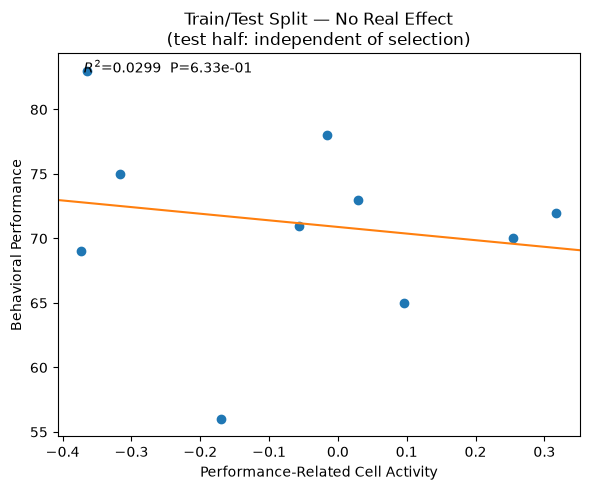

In [8]:
# Task 1.1 solution
def train_test_PRCA(DA, Perf, train_frac=0.5, generator=None):
    """Single train/test split: select cells on the training trial groups, then compute and
    return PRCA on the held-out test trial groups (which played no part in selection).

    Returns (PRCA_test, Perf_test, selected_cells), or None if no cells were selected.
    """
    Ng = DA.shape[0]
    idx = np.arange(Ng)
    if generator is not None:
        idx = generator.permutation(idx)  # randomize which groups are train vs test
    n_train = int(round(train_frac * Ng))
    train_idx, test_idx = idx[:n_train], idx[n_train:]

    res = stats.pearsonr(DA[train_idx], Perf[train_idx][:, np.newaxis], axis=0)
    sel = np.where((res.statistic > 0.1) & (res.pvalue < 0.05))[0]
    if sel.size == 0:
        return None
    PRCA_test = DA[test_idx][:, sel].mean(axis=1)
    return PRCA_test, Perf[test_idx], sel


# Apply the 50/50 split to the null data (contiguous first-half / second-half split).
split_null = train_test_PRCA(DA, Perf)
if split_null is None:
    print("Null data: no cells selected on the training half.")
else:
    PRCA_test_null, Perf_test_null, sel_null = split_null
    r_tt, p_tt = stats.pearsonr(PRCA_test_null, Perf_test_null)
    print("Null data — 50/50 train/test split:")
    print(f"  cells selected on training half : {sel_null.size}")
    print(f"  test-half correlation           : r = {r_tt:+.3f}, p = {p_tt:.3f}")

    fig, ax = plt.subplots(figsize=(6, 5))
    annotate_corr(ax, PRCA_test_null, Perf_test_null,
                  "Train/Test Split — No Real Effect\n(test half: independent of selection)")
    plt.tight_layout()
    plt.show()



<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

### Comparison plot: circular analysis vs. train-test split

Two panels show the scatter of PRCA vs. behavioral performance $P$ on the **null** data.
On the left is the circular analysis (same trial groups used to select and to test); on the
right is train-test split (each trial group's PRCA comes from cells selected on the *other* trial
groups). In the train-test split plot only trial groups whose fold produced at least one selected cell
are shown.

**Expected outcome:** the circular panel shows a spurious significant correlation while the
train-test split panel shows a weak, non-significant one ($p \gg 0.05$).

</div>


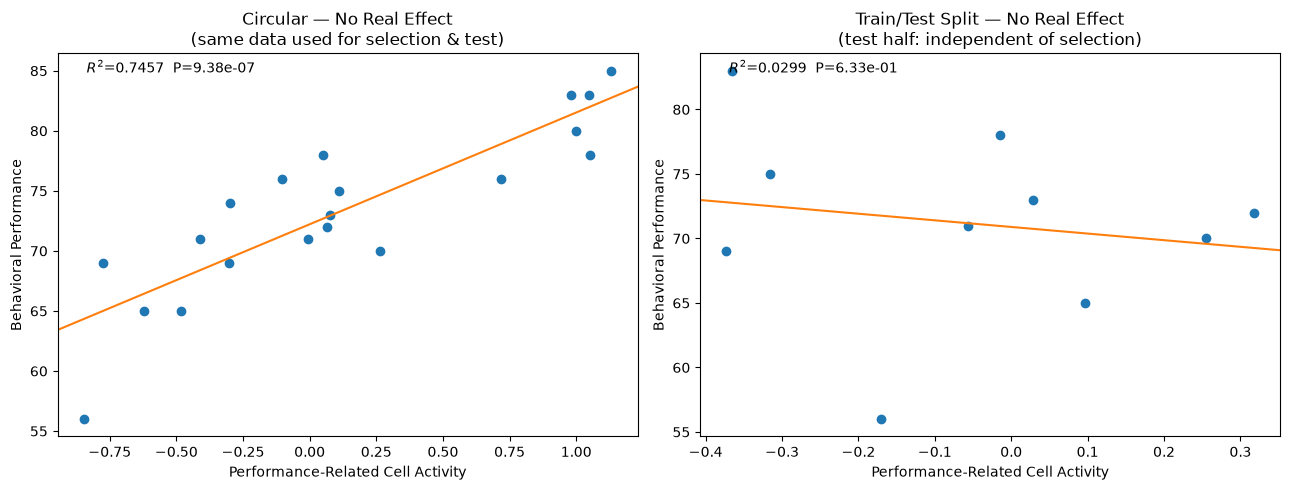

In [9]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
annotate_corr(axes[0], PRCA, Perf,
              "Circular — No Real Effect\n(same data used for selection & test)")
annotate_corr(axes[1], PRCA_test_null, Perf_test_null,
                "Train/Test Split — No Real Effect\n(test half: independent of selection)")
plt.tight_layout()
plt.show()



<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

## Solution 2: Multiple-comparison correction

The train-test split approach breaks the circularity by separating selection and testing. A different
valid strategy avoids the circular *average-and-retest* step altogether: rather than pooling
selected cells and re-testing their average, we can correct our selection criteria so we don't erroneously select 
cells that aren't truly correlated.

Viewed in this way, the problem is that if a single test has false positive rate 5% but we run it many times, the 
overall false positive rate increases and eventually approaches 100%. 

- **family-wise error rate (FWER)** correction controls the likelihood of *any* cell being falsely selected. A simple (conservative approach) is the **Bonferroni** procedure - simply multiply the p-values by the number of tests.
- **false discovery rate (FDR)** correction controls what percent of the selected cells are false positives (false discoveries). One approach is the **Benjamini-Hochberg** procedure, implemented in `scipy.stats.false_discovery_control`.

The number of significant cells is itself the read-out in this approach: if it is $\ge 1$ we would declare a
detected effect. Because each per-cell test uses the full data only *once* (no re-testing of a
selected average), this is not circular. We might plot the PRCA/performance relationship for visualization after, but that won't determine our conclusion.

</div>


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">
<p><b>Task 1.2:</b> Write a function that takes the <code>DA</code> and <code>Perf</code> arrays, runs <code>pearsonr</code> for every cell, then returns the indices of cells matching our selection criteria (<code>r &gt; 0.1</code> and <code>p &lt; 0.05</code>) after correcting for multiple comparisons (FWER via Bonferroni, or FDR via Benjamini-Hochberg).
</div>


In [10]:
# Task 1.2 solution

def fwer_cells(DA, Perf, q=0.05):
    """Select cells whose correlation with Perf survives Bonferroni at level q.

    Returns the indices of the surviving cells (the FDR-significant discoveries).
    """
    res = stats.pearsonr(DA, Perf[:, np.newaxis], axis=0)
    adj_p = res.pvalue * res.pvalue.size  # Bonferroni correction
    return np.where(adj_p <= q)[0]

def fdr_bh_cells(DA, Perf, q=0.05):
    """Select cells whose correlation with Perf survives BH-FDR at level q.

    Returns the indices of the surviving cells (the FDR-significant discoveries).
    """
    res = stats.pearsonr(DA, Perf[:, np.newaxis], axis=0)
    adj_p = stats.false_discovery_control(res.pvalue, method="bh")
    return np.where(adj_p <= q)[0]


q_fdr = 0.05
fdr_null = fdr_bh_cells(DA, Perf, q=q_fdr)
print(f"FDR-BH (q = {q_fdr}) cells discovered on null data: {fdr_null.size}")

fwer_null = fwer_cells(DA, Perf, q=0.05)
print(f"FWER (Bonferroni, q = 0.05) cells discovered on null data: {fwer_null.size}")

FDR-BH (q = 0.05) cells discovered on null data: 0
FWER (Bonferroni, q = 0.05) cells discovered on null data: 0



<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

### False-positive rate — three methods

A single simulation run is not enough to measure the false-positive rate — one run
either passes or fails the significance threshold by chance.  To estimate the actual
false-positive rate we repeat the **null simulation** (no real effect) many times and
count how often each method incorrectly declares a significant result.

The loop below runs `N_iter = 1000` fresh null datasets.  For each:

1. Draw new `DA` (`Perf` can stay fixed or be resampled also).
2. Run the **circular** analysis and record whether the final $p < \alpha$.
3. Run the **train/test split** analysis and record whether the test-half $p < \alpha$.
4. Run the **multiple comparison** analysis and record whether it declares $\ge 1$ significant cell at $q = \alpha$.

At $\alpha = 0.05$ the nominal false-positive rate is 5%.

| Method | Selection / test | Trial groups used for selection | Trial groups used for final test |
|---|---|---|---|
| Circular | Correlation with $P$, average, re-test | All 20 | Same 20 |
| Train/test split | Correlation with $P$ | 10 (train half) | 10 (test half) |
| Multiple comparison | Per-cell correlation with $P$, corrected | All 20 | All 20 (no re-test of an average) |

**Expected outcome:** circular far above nominal; the train/test split and FDR-BH near
nominal.

*(Leave-one-out cross-validation — a more data-efficient valid method — is introduced in its
own section below, along with related pitfalls)*

</div>


In [11]:
N_iter2 = 1000
alpha2 = 0.05

counts = {"circular": 0, "split": 0, "fdr_bh": 0}

for _ in range(N_iter2):
    DA_mc = sA * rng.standard_normal((Ngroups, Ncells))

    # Circular
    res_mc = stats.pearsonr(DA_mc, Perf[:, np.newaxis], axis=0)
    sel_mc = np.where((res_mc.statistic > 0.1) & (res_mc.pvalue < 0.05))[0]
    if sel_mc.size > 0:
        _, p_circ = stats.pearsonr(DA_mc[:, sel_mc].mean(axis=1), Perf)
        if p_circ < alpha2:
            counts["circular"] += 1

    # 50/50 train/test split
    tt = train_test_PRCA(DA_mc, Perf)
    if tt is not None and tt[0].size >= 3:
        _, p_tt = stats.pearsonr(tt[0], tt[1])
        if p_tt < alpha2:
            counts["split"] += 1

    # FDR-BH: declare an effect if >=1 cell survives BH at q = alpha2
    if fdr_bh_cells(DA_mc, Perf, q=alpha2).size > 0:
        counts["fdr_bh"] += 1

for name, cnt in counts.items():
    print(f"  {name:10s}  FP rate = {cnt/N_iter2:.1%}  ({cnt}/{N_iter2})")
print(f"  nominal α  = {alpha2:.1%}")


  circular    FP rate = 99.3%  (993/1000)
  split       FP rate = 6.1%  (61/1000)
  fdr_bh      FP rate = 5.4%  (54/1000)
  nominal α  = 5.0%


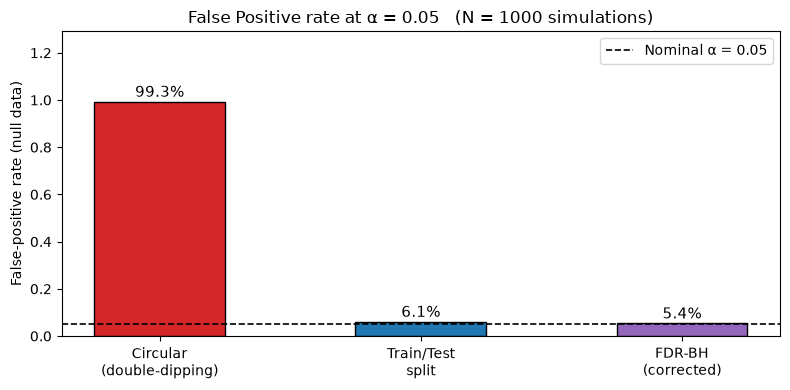

In [12]:
labels = ["Circular\n(double-dipping)", "Train/Test\nsplit", "FDR-BH\n(corrected)"]
rates2 = [counts[k] / N_iter2 for k in ("circular", "split", "fdr_bh")]
colors2 = ["tab:red", "tab:blue", "tab:purple"]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels, rates2, color=colors2, width=0.5, edgecolor="k")
ax.axhline(alpha2, color="k", linestyle="--", linewidth=1.2, label=f"Nominal α = {alpha2}")
ax.set_ylabel("False-positive rate (null data)")
ax.set_title(f"False Positive rate at α = {alpha2}   (N = {N_iter2} simulations)")
ax.set_ylim(0, max(rates2) * 1.3)
for bar, rate in zip(bars, rates2):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{rate:.1%}", ha="center", va="bottom", fontsize=11)
ax.legend()
plt.tight_layout()
plt.show()



<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

# Part 3 — Proposed analysis method, **with a real effect**

Now we repeat the entire simulation, but this time behavioral performance
really *does* modulate the activity of the **performance-correlated cells** (We simulate that **10% of the cells** are genuinely modulated by behavioral performance). For those cells we add, on top of the noise, a signal that is a scaled,
mean-zero function of each trial group's performance $P$:

$$P_\text{scaled} = \frac{k\, \sigma_A}{\operatorname{std}(P)}\,(P - \overline{P})$$

The constant `k` sets how big the behavioral effect is relative to noise:
`k=1` → the signal is comparable to the noise; `k=0.1` → performance only weakly affects it.
Here `k=0.2` gives a modest correlation. All other cells remain pure noise. Then the rest of
the analysis workflow is applied exactly as in Part 1.

</div>


In [13]:

Nresponsive = round(0.1 * Ncells)
# Indices of the cells that are genuinely modulated by performance (only in the real-effect case).
CorrelatedCells = np.arange(0, Nresponsive)
UncorrelatedCells = np.arange(Nresponsive, Ncells)

In [14]:
k = 0.2  # modest correlation between cell signal and performance
Pscaled = (k * sA / np.std(Perf, ddof=1)) * (Perf - np.mean(Perf))

DA_real = sA * rng.standard_normal((Ngroups, Ncells))
DA_real[:, CorrelatedCells] += Pscaled[:, np.newaxis]

r2 = np.empty(Ncells)
p2 = np.empty(Ncells)
for j in range(Ncells):
    r2[j], p2[j] = stats.pearsonr(DA_real[:, j], Perf)
SelectedCells_real = np.where((r2 > 0.1) & (p2 < 0.05))[0]
PRCA_real = DA_real[:, SelectedCells_real].mean(axis=1)
print(f"Number of 'selected' cells: {SelectedCells_real.size}")


Number of 'selected' cells: 4



<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

## Plot the real-effect result

Now run the same standard (circular) analysis on the real-effect data and plot PRCA vs.
performance. This time there genuinely is an effect — but note the circular plot looks much
like the null one, which is exactly why we can't trust the circular method on its own.

</div>


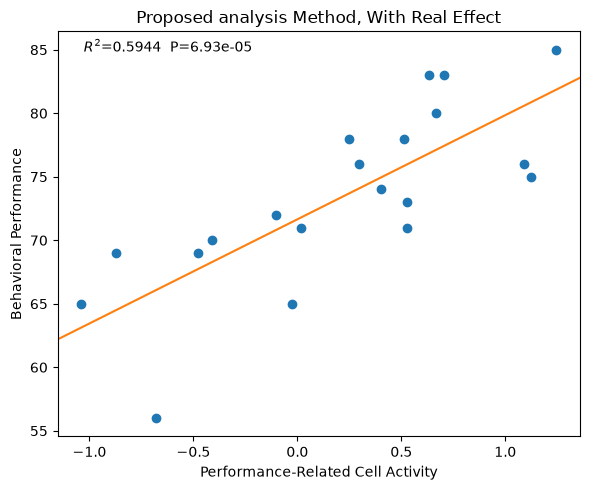

In [15]:
fig, ax = plt.subplots(figsize=(6, 5))
annotate_corr(ax, PRCA_real, Perf, "Proposed analysis Method, With Real Effect")
plt.tight_layout()
plt.show()



<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

## Where are the "correlated" cells? (spatial view)

Because each cell has a random 2D position, we can plot the imaging field and highlight the
subset of cells that the circular workflow *selected* as correlated with performance. Here we
show the **real-effect** data: the truly performance-correlated cells (the first
`Nresponsive` cells) are outlined for reference, and the selected set should overlap them more
often than chance — though, since positions are random, the selection still looks spatially
unstructured.

</div>


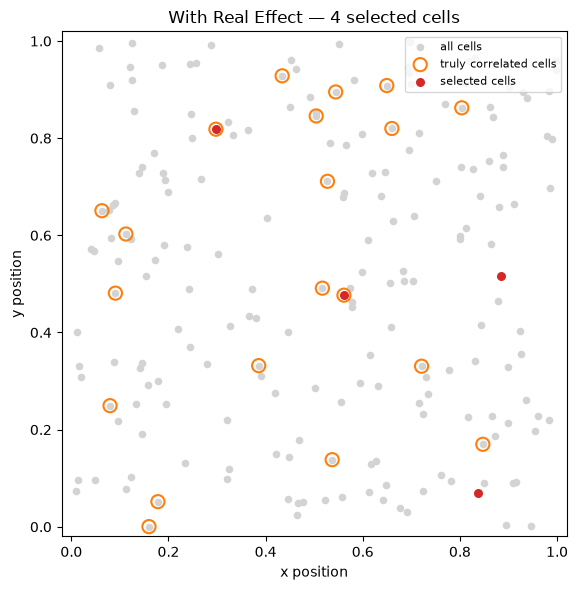

In [16]:
def plot_cells_2d(ax, selected, title, true_subset=None):
    """Plot all cells at their 2D positions, highlighting the `selected` subset."""
    ax.scatter(CellXY[:, 0], CellXY[:, 1], s=20, color="lightgray",
               label="all cells", zorder=1)
    if true_subset is not None:
        ax.scatter(CellXY[true_subset, 0], CellXY[true_subset, 1], s=90,
                   facecolors="none", edgecolors="tab:orange", linewidths=1.5,
                   label="truly correlated cells", zorder=2)
    ax.scatter(CellXY[selected, 0], CellXY[selected, 1], s=30, color="tab:red",
               label="selected cells", zorder=3)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_aspect("equal")
    ax.set_xlabel("x position")
    ax.set_ylabel("y position")
    ax.set_title(title)
    ax.legend(loc="upper right", fontsize=8)


fig, ax = plt.subplots(figsize=(7, 6))
plot_cells_2d(ax, SelectedCells_real,
              f"With Real Effect — {SelectedCells_real.size} selected cells",
              true_subset=CorrelatedCells)
plt.tight_layout()
plt.show()



<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

## Do the valid methods still detect the real effect?

Now apply the independent workflows — the 50/50 train/test split and FDR-BH — to
the **real-effect** data. Unlike the null case, here we *want* a detection. The valid methods
have lower power than the (invalid) circular method, but they should still pick up a genuine
effect, and their result can be trusted. (LOO-CV, introduced later, is a more data-efficient
alternative to the train/test split.)

</div>


In [17]:
# 50/50 train/test split on the real-effect data
split_real = train_test_PRCA(DA_real, Perf)

# FDR-BH on the real-effect data
fdr_real = fdr_bh_cells(DA_real, Perf, q=q_fdr)
true_hits = np.intersect1d(fdr_real, CorrelatedCells).size

print("Real-effect data (k = %.2f):" % k)
if split_real is None:
    print("  Train/test    : no cells selected on the training half")
else:
    r_tt_real, p_tt_real = stats.pearsonr(split_real[0], split_real[1])
    print(f"  Train/test    : r = {r_tt_real:+.3f}, p = {p_tt_real:.3f} "
          f"({split_real[2].size} cells selected on training half)")
print(f"  FDR-BH        : {fdr_real.size} cells discovered, "
      f"{true_hits}/{CorrelatedCells.size} are truly correlated")


Real-effect data (k = 0.20):
  Train/test    : r = +0.001, p = 0.999 (9 cells selected on training half)
  FDR-BH        : 0 cells discovered, 0/20 are truly correlated



<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

### Stronger effects
The train/test split prevents us from detecting the false positive in the no-real-effect dataset, but with the weak effect we may also fail to see a true positive result. What if we try increasing the strength of the real effect?

</div>


In [18]:
# simulate a stronger effect, k ~ 0.6
k_strong = 0.6  # stronger correlation between cell signal and performance
Pscaled_strong = (k_strong * sA / np.std(Perf, ddof=1)) * (Perf - np.mean(Perf))

DA_real_strong = sA * rng.standard_normal((Ngroups, Ncells))
DA_real_strong[:, CorrelatedCells] += Pscaled_strong[:, np.newaxis]

r2 = np.empty(Ncells)
p2 = np.empty(Ncells)
for j in range(Ncells):
    r2[j], p2[j] = stats.pearsonr(DA_real_strong[:, j], Perf)
SelectedCells_real_strong = np.where((r2 > 0.1) & (p2 < 0.05))[0]
PRCA_real_strong = DA_real_strong[:, SelectedCells_real_strong].mean(axis=1)
print(f"Number of 'selected' cells: {SelectedCells_real_strong.size}")


Number of 'selected' cells: 18


In [19]:
# Train/test split on the stronger-effect data
split_real_strong = train_test_PRCA(DA_real_strong, Perf)

print("Weak real-effect data (train/test split):")
r_w, p_w = stats.pearsonr(split_real[0], split_real[1])
print(f"  cells selected on training half : {split_real[2].size}")
print(f"  test-half correlation           : r = {r_w:+.3f}, p = {p_w:.3f}")

print("\nStrong real-effect data (train/test split):")
r_s, p_s = stats.pearsonr(split_real_strong[0], split_real_strong[1])
print(f"  cells selected on training half : {split_real_strong[2].size}")
print(f"  test-half correlation           : r = {r_s:+.3f}, p = {p_s:.3f}")


Weak real-effect data (train/test split):
  cells selected on training half : 9
  test-half correlation           : r = +0.001, p = 0.999

Strong real-effect data (train/test split):
  cells selected on training half : 14
  test-half correlation           : r = +0.785, p = 0.007


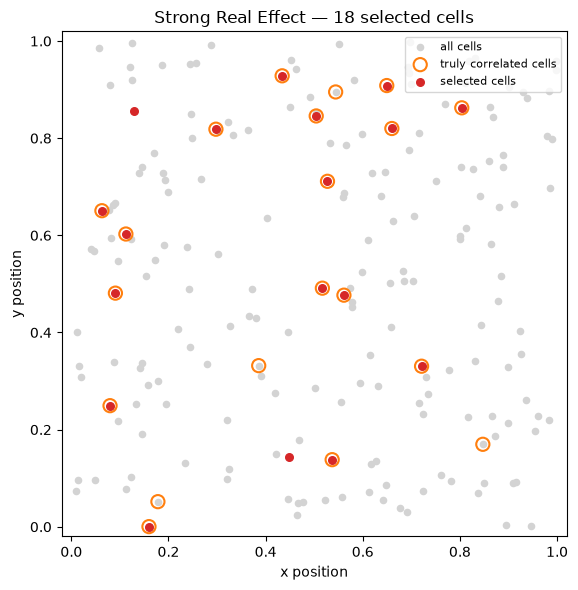

In [20]:
# reuse plot_cells_2d to plot the selected cells vs real cells 

fig, ax = plt.subplots(figsize=(7, 6))
plot_cells_2d(ax, SelectedCells_real_strong,
              f"Strong Real Effect — {SelectedCells_real_strong.size} selected cells",
              true_subset=CorrelatedCells)
plt.tight_layout()
plt.show()


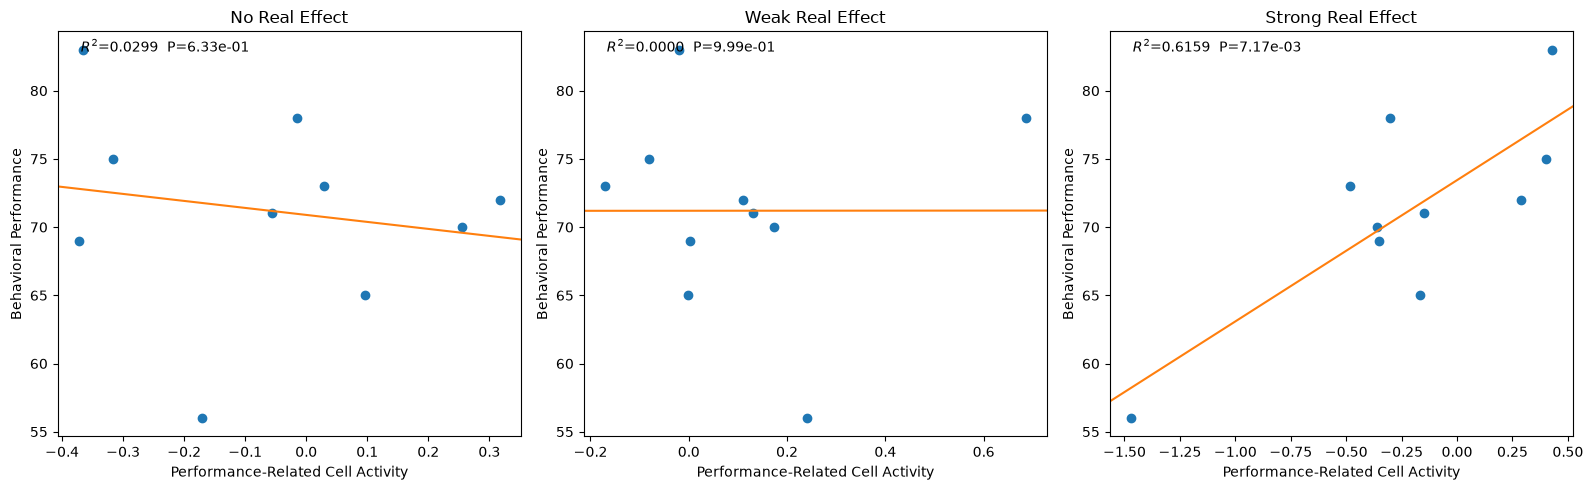

In [21]:
# Plot the train/test split results — no effect, weak effect, strong effect
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

panels = [
    (PRCA_test_null, Perf_test_null, "No Real Effect"), 
    (split_real[0], split_real[1], "Weak Real Effect"), 
    (split_real_strong[0], split_real_strong[1], "Strong Real Effect"),
]

for ax, (PRCA, perf, label) in zip(axes, panels):
    annotate_corr(ax, PRCA, perf, label)

plt.tight_layout()
plt.show()



<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

# Extension 1: Leave-one-out cross-validation
A problem with the simple train-test split solution above is that it reduces our effect dataset size by half, leaving us with less ability to detect real effects.

With only 20 trial groups, **leave-one-out cross-validation (LOO-CV)** is a natural choice:

* **Fold $i$** (for $i = 1 \ldots N_\text{groups}$):
  1. Use the $N_\text{groups} - 1$ *training* trial groups to select cells
     (same criteria as before: $r > 0.1$, $p < 0.05$).
  2. Compute the PRCA for the *held-out* trial group $i$ by averaging the
     activity in those training-derived cells.

After all folds, the held-out PRCA values are assembled into a vector of length
$N_\text{groups}$ and correlated with $P$.  Because no trial group's data influenced both the
cell-selection step and its own PRCA value, this correlation is (mostly) independent.

The helper below implements the loop; it returns `PRCA_cv` (one entry per trial group) and
the number of cells selected in each fold (useful for diagnostics).

</div>


In [22]:
def loo_cv_PRCA(DA, Perf):
    """Leave-one-out cross-validated PRCA.

    For each held-out trial group i, cells are selected on the other N-1 trial groups
    using the same criteria as the Proposed analysis (r > 0.1, p < 0.05),
    then PRCA is computed for trial group i on those held-out cells.

    Returns
    -------
    PRCA_cv : ndarray, shape (Ngroups,)
        Cross-validated PRCA; NaN where no cells were selected in that fold.
    n_cells : list of int
        Number of cells selected in each fold (diagnostic).
    """
    Ngroups = DA.shape[0]
    PRCA_cv = np.full(Ngroups, np.nan)
    n_cells = []

    for i in range(Ngroups):
        train_idx = np.delete(np.arange(Ngroups), i)
        # Correlate every cell with performance on the training folds (vectorized pearsonr).
        res = stats.pearsonr(DA[train_idx], Perf[train_idx][:, np.newaxis], axis=0)
        sel_cells = np.where((res.statistic > 0.1) & (res.pvalue < 0.05))[0]
        n_cells.append(sel_cells.size)
        if sel_cells.size > 0:
            PRCA_cv[i] = DA[i, sel_cells].mean()

    return PRCA_cv, n_cells
